In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pickle

In [2]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Explainatory Data Analysis (EDA)

In [3]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [4]:
# Shape of the dataset
df.shape

(1470, 35)

In [5]:
# Check for missing values
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

C:\Users\Rakhitha\AppData\Local\Temp\ipykernel_3996\2983145002.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition', data=df, palette='Set2')


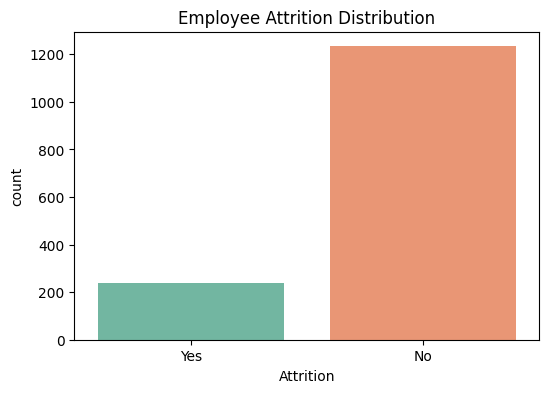

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df, palette='Set2')
plt.title("Employee Attrition Distribution")
plt.show()

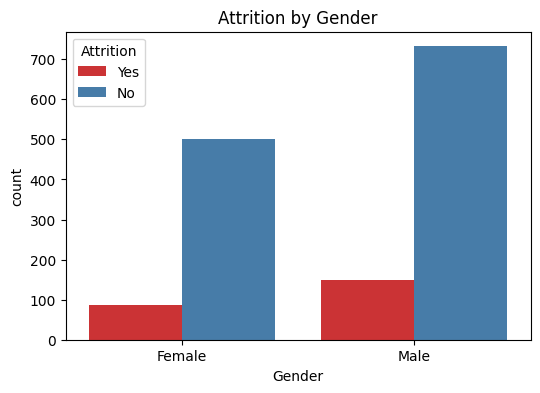

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Attrition', data=df, palette='Set1')
plt.title("Attrition by Gender")
plt.show()

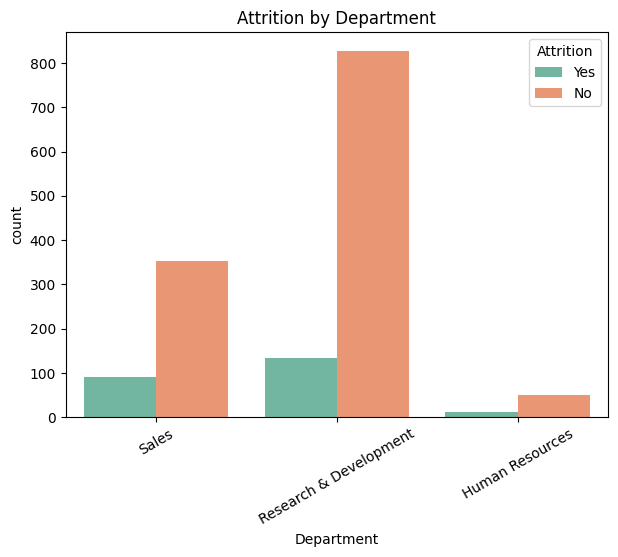

In [8]:
plt.figure(figsize=(7,5))
sns.countplot(x='Department', hue='Attrition', data=df, palette='Set2')
plt.title("Attrition by Department")
plt.xticks(rotation=30)
plt.show()

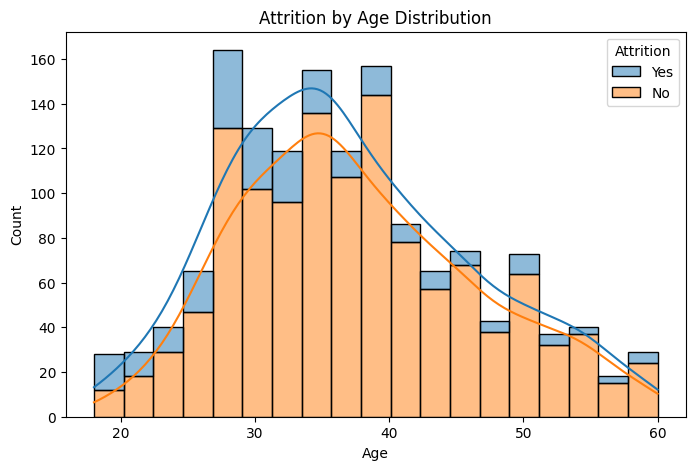

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Age', hue='Attrition', kde=True, multiple='stack')
plt.title("Attrition by Age Distribution")
plt.show()

C:\Users\Rakhitha\AppData\Local\Temp\ipykernel_3996\3026452419.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette='Set3')


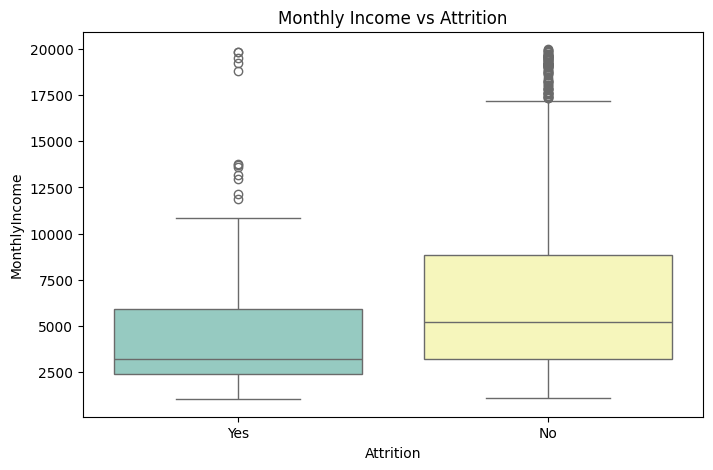

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette='Set3')
plt.title("Monthly Income vs Attrition")
plt.show()

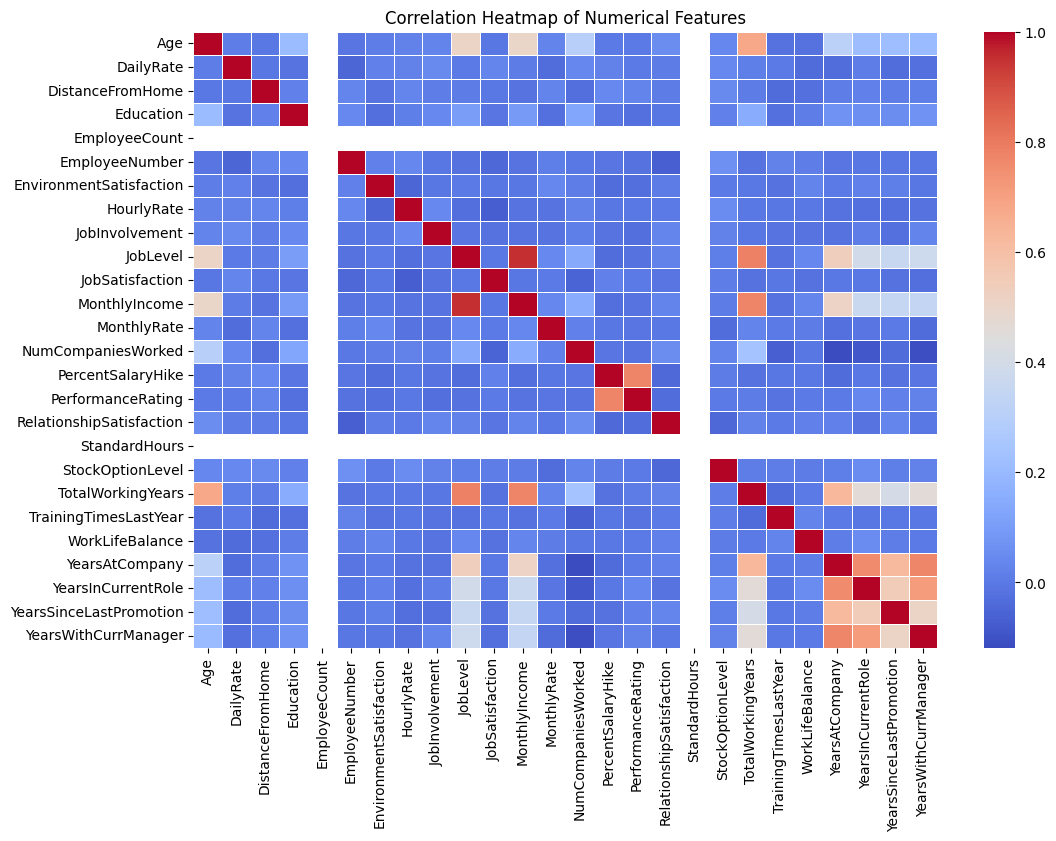

In [11]:
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [12]:
# Attrition distribution
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [13]:
# Identify feature types
target_column = 'Attrition'
categorical_features = []
numerical_features = []

for column in df.columns:
    if column == target_column:
        continue
    elif df[column].dtype == 'object' or df[column].nunique() < 10:
        categorical_features.append(column)
    else:
        numerical_features.append(column)

print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Numerical features ({len(numerical_features)}): {numerical_features}")

Categorical features (20): ['BusinessTravel', 'Department', 'Education', 'EducationField', 'EmployeeCount', 'EnvironmentSatisfaction', 'Gender', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'Over18', 'OverTime', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TrainingTimesLastYear', 'WorkLifeBalance']
Numerical features (14): ['Age', 'DailyRate', 'DistanceFromHome', 'EmployeeNumber', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


# Detect outliers using IQR
outlier_indices = set()
for feature in numerical_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    feature_outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)].index
    outlier_indices.update(feature_outliers)
    print(f"{feature}: {len(feature_outliers)} outliers detected")
print(f"Total unique outlier records: {len(outlier_indices)}")

In [14]:
# Detect outliers using IQR
outlier_indices = set()
for feature in numerical_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    feature_outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)].index
    outlier_indices.update(feature_outliers)
    print(f"{feature}: {len(feature_outliers)} outliers detected")
print(f"Total unique outlier records: {len(outlier_indices)}")

Age: 0 outliers detected
DailyRate: 0 outliers detected
DistanceFromHome: 0 outliers detected
EmployeeNumber: 0 outliers detected
HourlyRate: 0 outliers detected
MonthlyIncome: 114 outliers detected
MonthlyRate: 0 outliers detected
NumCompaniesWorked: 52 outliers detected
PercentSalaryHike: 0 outliers detected
TotalWorkingYears: 63 outliers detected
YearsAtCompany: 104 outliers detected
YearsInCurrentRole: 21 outliers detected
YearsSinceLastPromotion: 107 outliers detected
YearsWithCurrManager: 14 outliers detected
Total unique outlier records: 283


# Preprocessing

In [15]:
# Create a clean dataset by removing outlier records
df_clean = df.drop(index=outlier_indices)

In [16]:
# Reset index if needed
df_clean = df_clean.reset_index(drop=True)

# Verify outliers are removed by checking a few features
print("\nVerification - outliers remaining after cleaning:")
for feature in ['MonthlyIncome', 'NumCompaniesWorked', 'TotalWorkingYears']:
    if feature in numerical_features:
        Q1 = df_clean[feature].quantile(0.25)
        Q3 = df_clean[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        remaining_outliers = df_clean[(df_clean[feature] < lower_bound) | (df_clean[feature] > upper_bound)]
        print(f"{feature}: {len(remaining_outliers)} outliers remaining")


Verification - outliers remaining after cleaning:
MonthlyIncome: 43 outliers remaining
NumCompaniesWorked: 0 outliers remaining
TotalWorkingYears: 29 outliers remaining


In [17]:
# Attrition distribution
df_clean['Attrition'].value_counts()

Attrition
No     981
Yes    206
Name: count, dtype: int64

In [18]:
import pandas as pd
from sklearn.utils import resample

df_no = df_clean[df_clean['Attrition'] == 'No']
df_yes = df_clean[df_clean['Attrition'] == 'Yes']

# Upsample minority class
df_yes_upsampled = resample(df_yes,
                            replace=True,          # sample with replacement
                            n_samples=len(df_no),  # match number of majority class
                            random_state=42)       # reproducible results

# Combine majority and upsampled minority
df_balanced = pd.concat([df_no, df_yes_upsampled])

# Shuffle the dataframe
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_balanced['Attrition'].value_counts())


Attrition
Yes    981
No     981
Name: count, dtype: int64


In [19]:
# Drop useless columns
df_balanced.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis="columns", inplace=True)

categorical_col = []
for column in df_balanced.columns:
    # Safely skip 'Attrition' so we don't have to remove it later
    if column != 'Attrition' and df_balanced[column].dtype == object and len(df_balanced[column].unique()) <= 50:
        categorical_col.append(column)

# Convert Attrition to numbers (0 for No, 1 for Yes)
df_balanced['Attrition'] = df_balanced.Attrition.astype("category").cat.codes

print(categorical_col)

label_encoders = {}  # dictionary to store encoders

for column in categorical_col:
    le = LabelEncoder()
    df_balanced[column] = le.fit_transform(df_balanced[column])
    label_encoders[column] = le  # save encoder for this column

# Save all label encoders to a file
with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

[]


In [20]:
X = df_balanced.drop('Attrition', axis=1)
y = df_balanced.Attrition

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [21]:
X_train.isnull().sum()

Age                         0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

In [22]:
# Save datasets
with open('X_train.pkl', 'wb') as f:
    pickle.dump(X_train, f)

with open('X_test.pkl', 'wb') as f:
    pickle.dump(X_test, f)

with open('y_train.pkl', 'wb') as f:
    pickle.dump(y_train, f)

with open('y_test.pkl', 'wb') as f:
    pickle.dump(y_test, f)